In [1]:
!pip install finance-datareader

   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 4.0/4.0 MB 60.6 MB/s  0:00:00
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 9.9/9.9 MB 77.1 MB/s  0:00:00

   ------ --------------------------------- 1/6 [narwhals]
   ------ --------------------------------- 1/6 [narwhals]
   ------ --------------------------------- 1/6 [narwhals]
   ------ --------------------------------- 1/6 [narwhals]
   ------------- -------------------------- 2/6 [lxml]
   -------------------------- ------------- 4/6 [plotly]
   -------------------------- ------------- 4/6 [plotly]
   -------------------------- ------------- 4/6 [plotly]
   -------------------------- ------------- 4/6 [plotly]
   -------------------------- ------------- 4/6 [plotly]
   -------------------------- ------------- 4/6 [plotly]
   -------------------------- ------------- 4/6 [plotly]
   --------------------

In [14]:
import FinanceDataReader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM

In [3]:
samsug = pd.read_csv('dataset/samsung_2024.csv')
samsug

,Date,Open,High,Low,Close,Volume,Change
0,2024-01-02,78200,79800,78200,79600,17142847,0.014013
1,2024-01-03,78500,78800,77000,77000,21753644,-0.032663
2,2024-01-04,76100,77300,76100,76600,15324439,-0.005195
3,2024-01-05,76700,77100,76400,76600,11304316,0.000000
4,2024-01-08,77000,77500,76400,76500,11088724,-0.001305
...,...,...,...,...,...,...,...
572,2026-05-12,290000,291500,266000,279000,41211149,-0.022767
573,2026-05-13,264000,285500,262000,284000,35540134,0.017921
574,2026-05-14,282000,299500,282000,296000,39314752,0.042254
575,2026-05-15,291000,296500,266000,270500,38075487,-0.086149


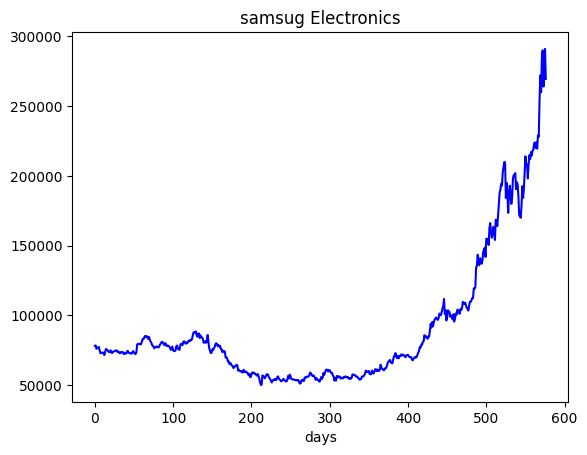

In [5]:
seq_data = (samsug[['Open']]).to_numpy()
plt.plot(seq_data,color='blue')
plt.title('samsug Electronics')
plt.xlabel('days')
plt.show()

In [10]:
def make_sample(data,window):
    train=[]
    target = []
    for i in range(len(data)-window):
        train.append(data[i: i+window])
        target.append(data[i+window])
    return np.array(train),np.array(target)
X,y = make_sample(seq_data,7)
print(X.shape,y.shape)
print(X[0],y[0])

(570, 7, 1) (570, 1)
[[78200]
 [78500]
 [76100]
 [76700]
 [77000]
 [77400]
 [75000]] [72900]


In [31]:
openValues = samsug[['Open']]

scaler = MinMaxScaler(feature_range=(0,1))
scaled = scaler.fit_transform(openValues)

test_size=200
train_data=scaled[:-test_size]
test_data = scaled[-test_size:]

In [32]:
def make_sample(data,window):
    train=[]
    target = []
    for i in range(len(data)-window):
        train.append(data[i: i+window])
        target.append(data[i+window])
    return np.array(train),np.array(target)
X_train,y_train = make_sample(train_data,30)

In [33]:
# return_sequences=False : 출력 시퀀스의 마지막 출력만 반환

model = Sequential()
model.add(LSTM(16,input_shape=(X_train.shape[1],1),
              activation='relu',
              return_sequences=False))

model.add(Dense(1))

model.compile(optimizer='adam',loss='mean_squared_error')
model.fit(X_train,y_train,epochs=100,batch_size=16)

Epoch 1/100
22/22 [==============================] - 3s 77ms/step - loss: 0.0030
Epoch 2/100
22/22 [==============================] - 1s 56ms/step - loss: 0.0013
Epoch 3/100
22/22 [==============================] - 1s 52ms/step - loss: 7.8299e-04
Epoch 4/100
22/22 [==============================] - 1s 54ms/step - loss: 4.4988e-04
Epoch 5/100
22/22 [==============================] - 1s 55ms/step - loss: 1.7884e-04
Epoch 6/100
22/22 [==============================] - 1s 52ms/step - loss: 1.2393e-04
Epoch 7/100
22/22 [==============================] - 1s 50ms/step - loss: 1.1143e-04
Epoch 8/100
22/22 [==============================] - 1s 51ms/step - loss: 1.1225e-04
Epoch 9/100
22/22 [==============================] - 1s 51ms/step - loss: 1.0464e-04
Epoch 10/100
22/22 [==============================] - 1s 53ms/step - loss: 1.0370e-04
Epoch 11/100
22/22 [==============================] - 1s 52ms/step - loss: 1.0467e-04
Epoch 12/100
22/22 [==============================] - 1s 53ms/step - lo

In [34]:
X_test,y_test = make_sample(test_data,30)
pred = model.predict(X_test)

6/6 [==============================] - 0s 8ms/step


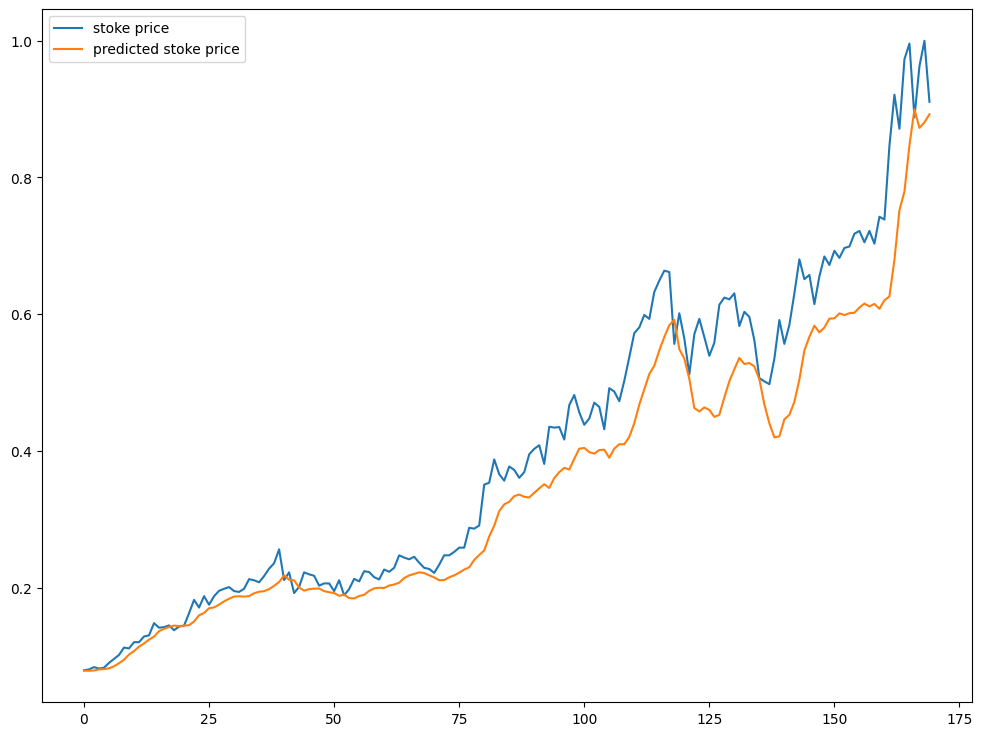

In [35]:
plt.figure(figsize=(12,9))
plt.plot(y_test,label='stoke price')
plt.plot(pred,label='predicted stoke price')
plt.legend()
plt.show()